In [12]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('../data/cleaned_wastewater.csv')

df.head()

,source_id,source_name,source_type,iso3_country,sector,subsector,start_time,end_time,lat,lon,...,temporal_granularity,activity,activity_units,emissions_factor,emissions_factor_units,capacity,capacity_units,capacity_factor,created_date,modified_date
0,4416905,Unknown name,steel,ALB,waste,industrial-wastewater-treatment-and-discharge,2021-01-01,2021-01-31,41.094611,20.026117,...,month,4246.915068,tonnes of Product,0,t of CO2 per tonnes of Product,4246.915068,tonnes of Product,1,2024-09-20,2026-04-10 05:02:16.862423
1,4416905,Unknown name,steel,ALB,waste,industrial-wastewater-treatment-and-discharge,2021-02-01,2021-02-28,41.094611,20.026117,...,month,3835.923288,tonnes of Product,0,t of CO2 per tonnes of Product,3835.923288,tonnes of Product,1,2024-09-20,2026-04-10 05:02:16.862423
2,4416905,Unknown name,steel,ALB,waste,industrial-wastewater-treatment-and-discharge,2021-03-01,2021-03-31,41.094611,20.026117,...,month,4246.915068,tonnes of Product,0,t of CO2 per tonnes of Product,4246.915068,tonnes of Product,1,2024-09-20,2026-04-10 05:02:16.862423
3,4416905,Unknown name,steel,ALB,waste,industrial-wastewater-treatment-and-discharge,2021-04-01,2021-04-30,41.094611,20.026117,...,month,4109.917808,tonnes of Product,0,t of CO2 per tonnes of Product,4109.917808,tonnes of Product,1,2024-09-20,2026-04-10 05:02:16.862423
4,4416905,Unknown name,steel,ALB,waste,industrial-wastewater-treatment-and-discharge,2021-05-01,2021-05-31,41.094611,20.026117,...,month,4246.915068,tonnes of Product,0,t of CO2 per tonnes of Product,4246.915068,tonnes of Product,1,2024-09-20,2026-04-10 05:02:16.862423


In [14]:
df.shape

(79112, 22)

In [15]:
country_emissions = (
    df.groupby('iso3_country')['emissions_quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_emissions

iso3_country
ALB    0
OMN    0
QAT    0
PRT    0
PRK    0
POL    0
PHL    0
PER    0
PAK    0
NZL    0
Name: emissions_quantity, dtype: int64

In [16]:
df[['iso3_country', 'gas', 'emissions_quantity']].head(20)

,iso3_country,gas,emissions_quantity
0,ALB,co2,0
1,ALB,co2,0
2,ALB,co2,0
3,ALB,co2,0
4,ALB,co2,0
5,ALB,co2,0
6,ALB,co2,0
7,ALB,co2,0
8,ALB,co2,0
9,ALB,co2,0


In [17]:
df['emissions_quantity'].unique()[:20]

array([0])

In [18]:
numeric_cols = [
    'activity',
    'emissions_factor',
    'capacity',
    'capacity_factor'
]

df[numeric_cols].describe()

,activity,emissions_factor,capacity,capacity_factor
count,7.911200e+04,79112.0,7.911200e+04,79112.0
mean,1.004702e+05,0.0,1.004702e+05,1.0
std,1.647362e+05,0.0,1.647362e+05,0.0
min,0.000000e+00,0.0,0.000000e+00,1.0
25%,1.494081e+04,0.0,1.494081e+04,1.0
50%,4.994975e+04,0.0,4.994975e+04,1.0
75%,1.052635e+05,0.0,1.052635e+05,1.0
max,1.741436e+06,0.0,1.741436e+06,1.0


In [19]:
country_activity = (
    df.groupby('iso3_country')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_activity

iso3_country
CHN    3.363885e+09
USA    6.459060e+08
JPN    4.306901e+08
IND    4.298042e+08
RUS    3.734710e+08
KOR    3.088238e+08
BRA    2.732479e+08
TUR    1.809665e+08
DEU    1.808272e+08
IRN    1.521654e+08
Name: activity, dtype: float64

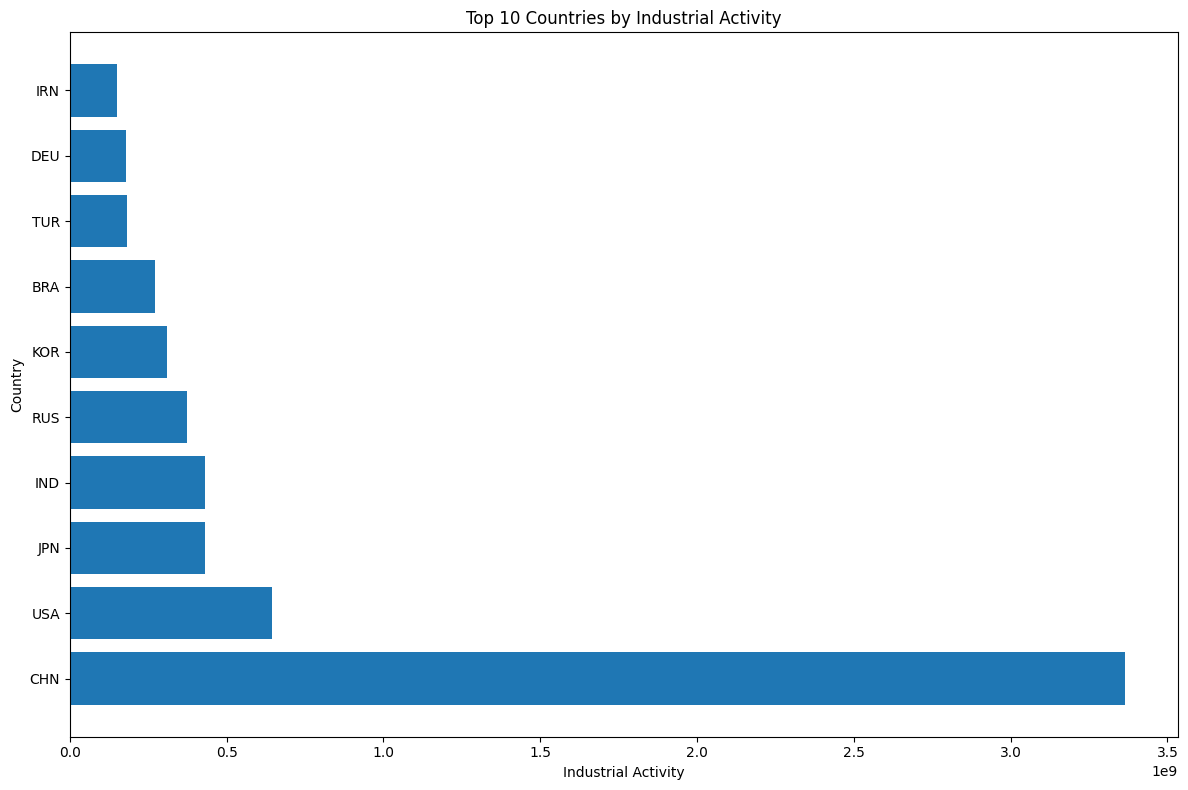

In [20]:
plt.figure(figsize=(12,8))

plt.barh(
    country_activity.index,
    country_activity.values
)

plt.title('Top 10 Countries by Industrial Activity')

plt.xlabel('Industrial Activity')

plt.ylabel('Country')

plt.tight_layout()

plt.show()

In [21]:
industry_activity = (
    df.groupby('source_type')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

industry_activity

source_type
steel             7.191219e+09
pulp and paper    7.571772e+08
Name: activity, dtype: float64

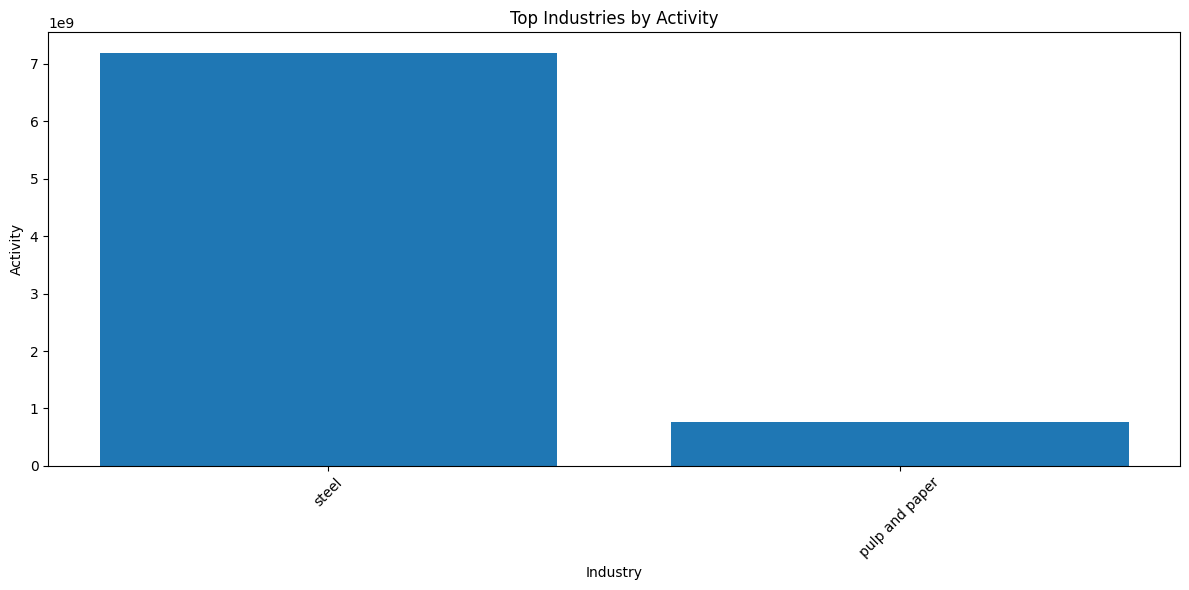

In [22]:
plt.figure(figsize=(12,6))

plt.bar(
    industry_activity.index,
    industry_activity.values
)

plt.xticks(rotation=45)

plt.title('Top Industries by Activity')

plt.xlabel('Industry')

plt.ylabel('Activity')

plt.tight_layout()

plt.show()

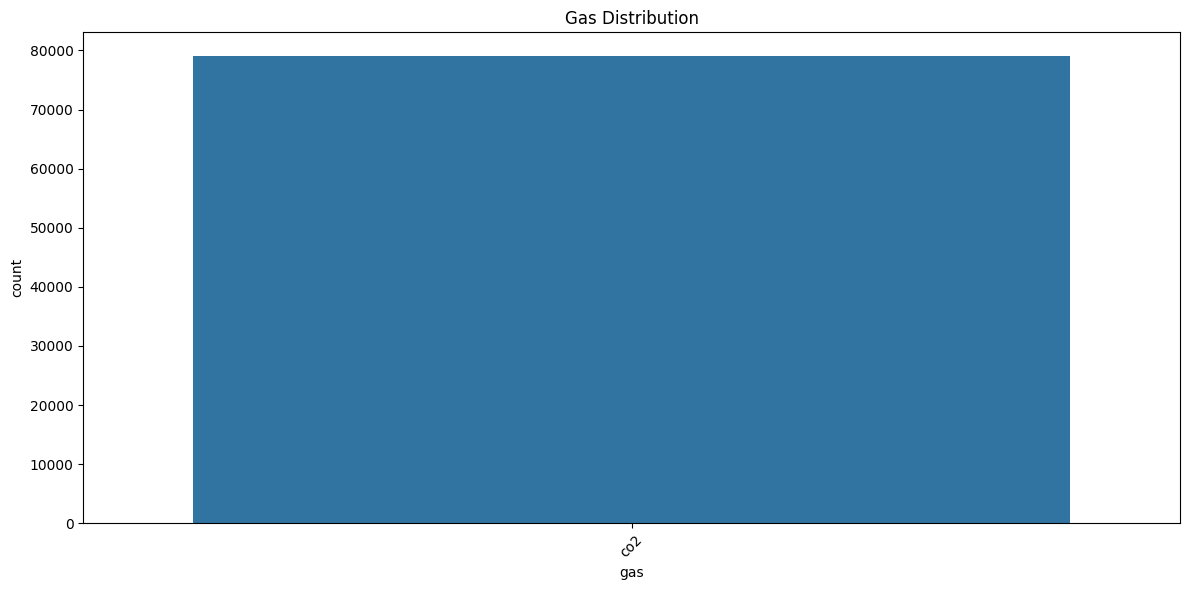

In [23]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='gas'
)

plt.xticks(rotation=45)

plt.title('Gas Distribution')

plt.tight_layout()

plt.show()

In [24]:
df['iso3_country'].value_counts().head(15)

iso3_country
CHN    20956
USA    10044
IND     6014
CAN     3658
JPN     2728
BRA     2666
RUS     2542
SWE     2170
IRN     2046
TUR     1674
ITA     1612
DEU     1364
ESP     1302
FIN     1178
IDN     1054
Name: count, dtype: int64

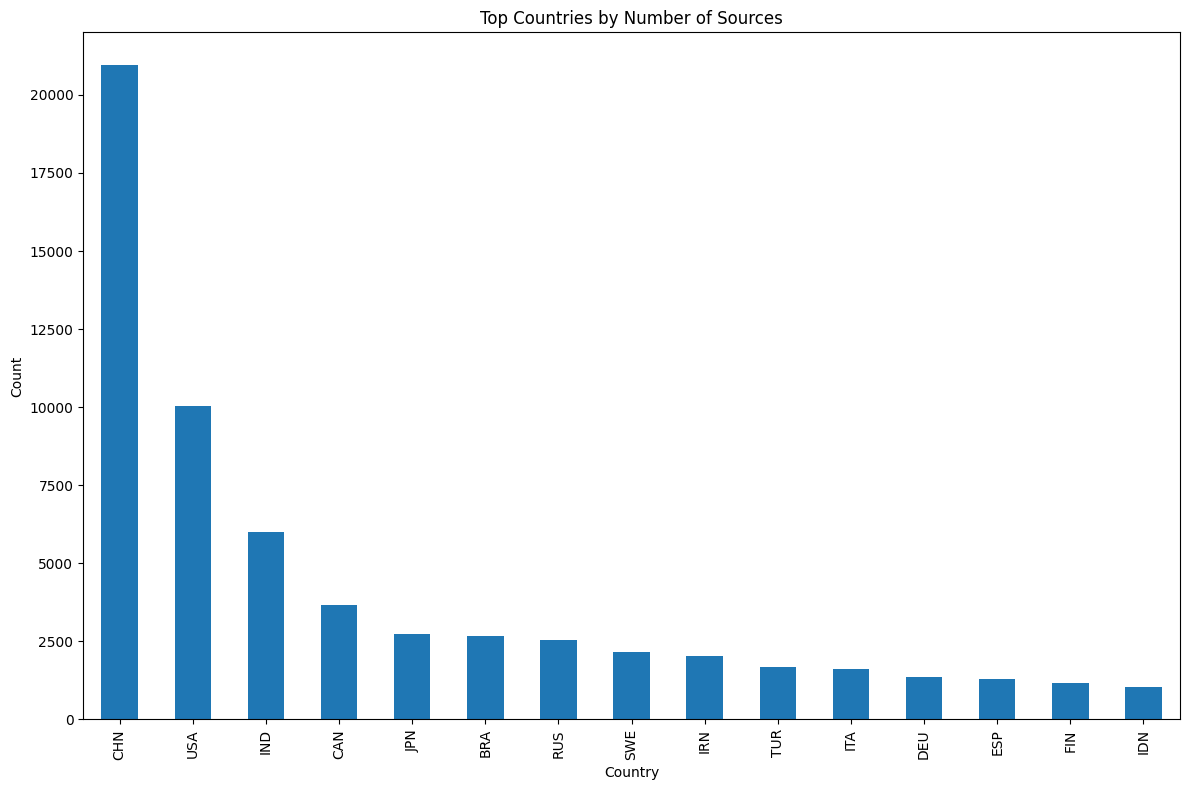

In [25]:
plt.figure(figsize=(12,8))

df['iso3_country'].value_counts().head(15).plot(kind='bar')

plt.title('Top Countries by Number of Sources')

plt.xlabel('Country')

plt.ylabel('Count')

plt.tight_layout()

plt.show()

In [26]:
df['gas'].value_counts()

gas
co2    79112
Name: count, dtype: int64

In [27]:
sector_activity = (
    df.groupby('sector')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sector_activity

sector
waste    7.948396e+09
Name: activity, dtype: float64

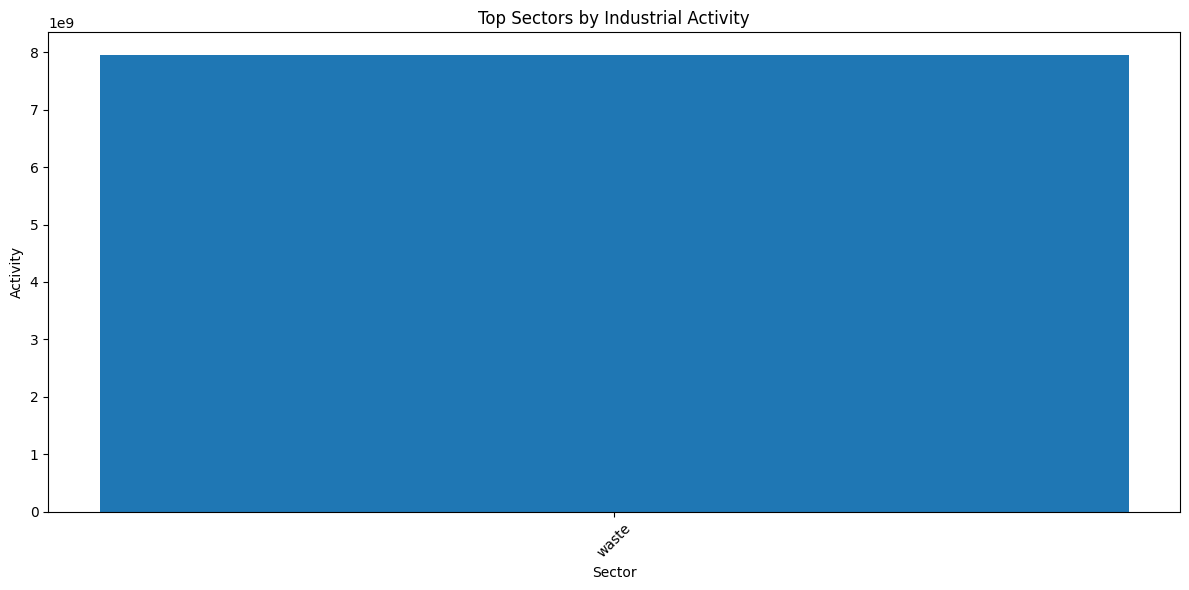

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    sector_activity.index,
    sector_activity.values
)

plt.xticks(rotation=45)

plt.title('Top Sectors by Industrial Activity')

plt.xlabel('Sector')

plt.ylabel('Activity')

plt.tight_layout()

plt.show()

In [32]:
df['source_type']

0        steel
1        steel
2        steel
3        steel
4        steel
         ...  
79107    steel
79108    steel
79109    steel
79110    steel
79111    steel
Name: source_type, Length: 79112, dtype: str

In [33]:
country_activity = (
    df.groupby('iso3_country')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_activity

iso3_country
CHN    3.363885e+09
USA    6.459060e+08
JPN    4.306901e+08
IND    4.298042e+08
RUS    3.734710e+08
KOR    3.088238e+08
BRA    2.732479e+08
TUR    1.809665e+08
DEU    1.808272e+08
IRN    1.521654e+08
IDN    1.181385e+08
ITA    1.153666e+08
CAN    9.428108e+07
MEX    9.280163e+07
VNM    8.920768e+07
Name: activity, dtype: float64

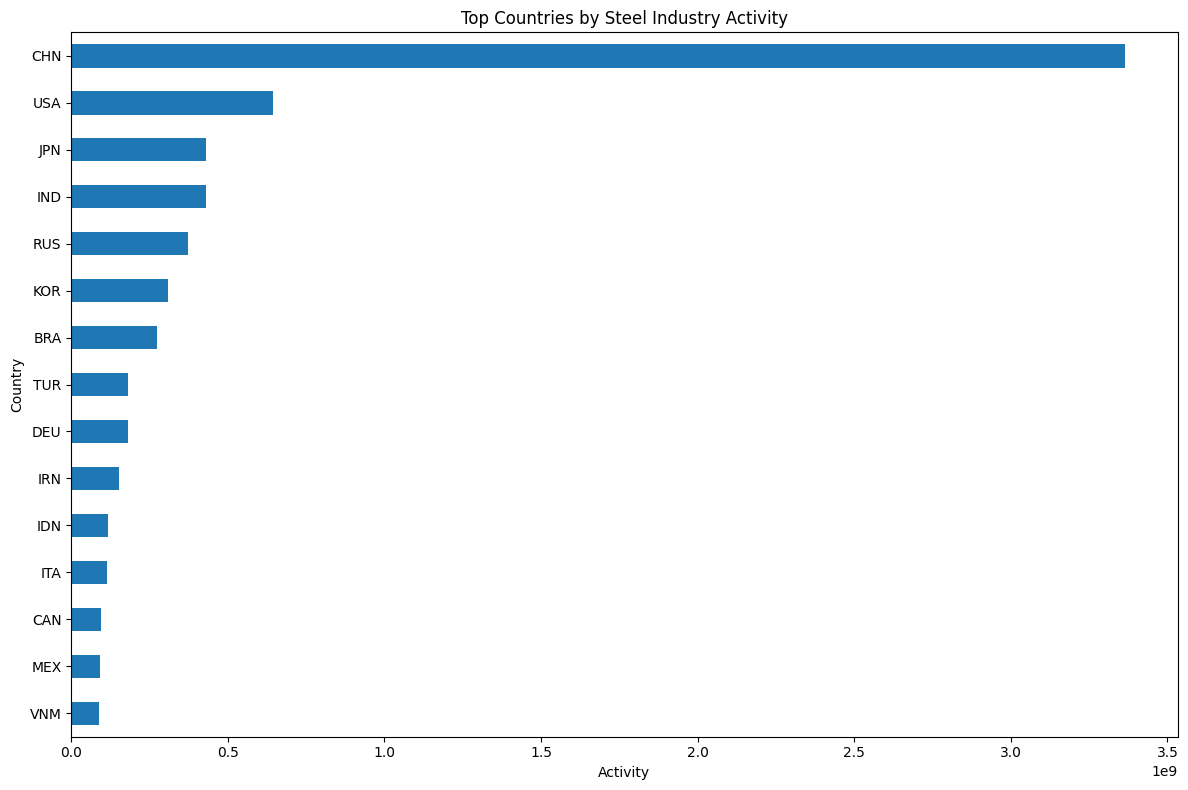

In [34]:
plt.figure(figsize=(12,8))

country_activity.sort_values().plot(kind='barh')

plt.title('Top Countries by Steel Industry Activity')

plt.xlabel('Activity')

plt.ylabel('Country')

plt.tight_layout()

plt.show()

In [35]:
df['subsector'].value_counts().head(20)

subsector
industrial-wastewater-treatment-and-discharge    79112
Name: count, dtype: int64

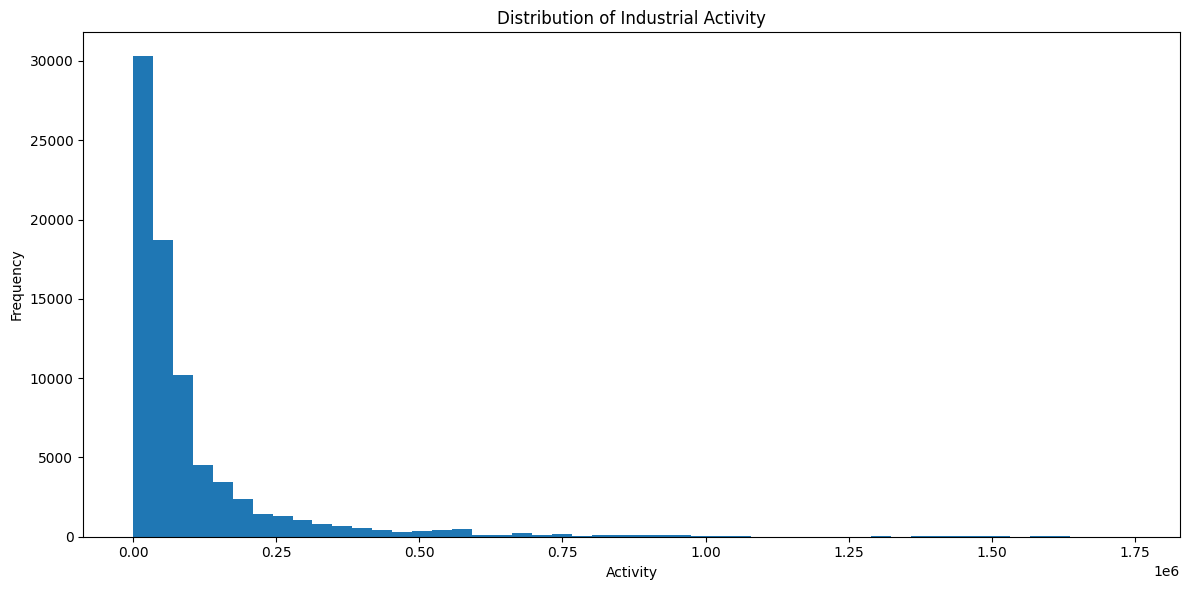

In [36]:
plt.figure(figsize=(12,6))

plt.hist(
    df['activity'],
    bins=50
)

plt.title('Distribution of Industrial Activity')

plt.xlabel('Activity')

plt.ylabel('Frequency')

plt.tight_layout()

plt.show()

In [37]:
country_activity = (
    df.groupby('iso3_country')['activity']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

country_activity

iso3_country
CHN    3.363885e+09
USA    6.459060e+08
JPN    4.306901e+08
IND    4.298042e+08
RUS    3.734710e+08
KOR    3.088238e+08
BRA    2.732479e+08
TUR    1.809665e+08
DEU    1.808272e+08
IRN    1.521654e+08
IDN    1.181385e+08
ITA    1.153666e+08
CAN    9.428108e+07
MEX    9.280163e+07
VNM    8.920768e+07
Name: activity, dtype: float64

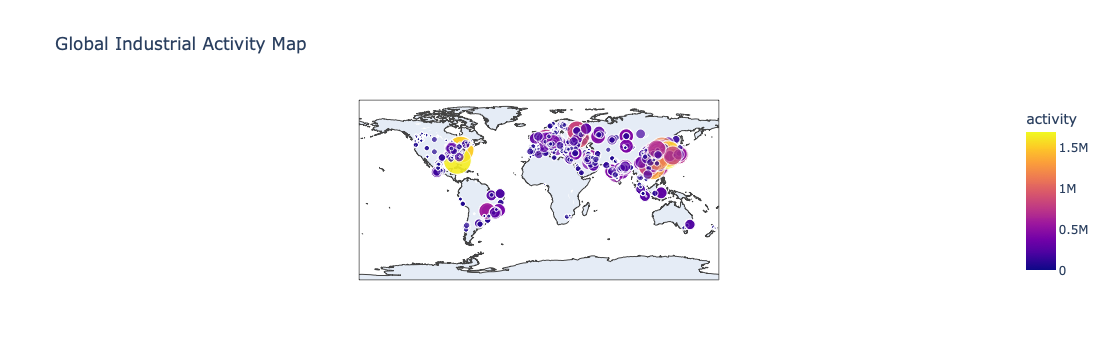

In [38]:
import plotly.express as px

sample_df = df.sample(3000)

fig = px.scatter_geo(
    sample_df,
    lat='lat',
    lon='lon',
    size='activity',
    color='activity',
    hover_name='iso3_country',
    title='Global Industrial Activity Map'
)

fig.show()